In [1]:
import pandas as pd
url="https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=10000&$where=created_date%20%3C%20%272024-01-01%27%20AND%20created_date%20%3E%20%272023-01-01%27"
df=pd.read_csv(url)
print(df.shape)

(10000, 44)


In [2]:
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,59889383,2023-12-31T23:59:42.000,2024-01-01T01:51:01.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11375.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.734695,-73.850521,POINT (-73.850521255774 40.734694673156)
1,59887573,2023-12-31T23:59:39.000,2024-01-19T14:37:37.000,EDC,Economic Development Corporation,Noise - Helicopter,Other,Flying Too Low,Above Address,10023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.777201,-73.976159,POINT (-73.976158989108 40.777201024559)
2,59892892,2023-12-31T23:59:29.000,2024-01-01T04:06:24.000,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11355.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.759286,-73.822614,POINT (-73.822613866961 40.759286493466)
3,59893860,2023-12-31T23:59:29.000,2024-01-01T01:51:32.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11374.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.729379,-73.855433,POINT (-73.855432907851 40.72937885746)
4,59887231,2023-12-31T23:59:23.000,2024-01-01T00:13:30.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11232.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644725,-73.997622,POINT (-73.997621713538 40.64472479285)


In [3]:
df.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'descriptor_2', 'location_type',
       'incident_zip', 'incident_address', 'street_name', 'cross_street_1',
       'cross_street_2', 'intersection_street_1', 'intersection_street_2',
       'address_type', 'city', 'landmark', 'facility_type', 'status',
       'due_date', 'resolution_description', 'resolution_action_updated_date',
       'community_board', 'council_district', 'police_precinct', 'bbl',
       'borough', 'x_coordinate_state_plane', 'y_coordinate_state_plane',
       'open_data_channel_type', 'park_facility_name', 'park_borough',
       'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location',
       'bridge_highway_name', 'bridge_highway_direction', 'road_ramp',
       'bridge_highway_segment', 'latitude', 'longitude', 'location'],
      dtype='object')

In [4]:
print(df.columns.tolist())

['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name', 'complaint_type', 'descriptor', 'descriptor_2', 'location_type', 'incident_zip', 'incident_address', 'street_name', 'cross_street_1', 'cross_street_2', 'intersection_street_1', 'intersection_street_2', 'address_type', 'city', 'landmark', 'facility_type', 'status', 'due_date', 'resolution_description', 'resolution_action_updated_date', 'community_board', 'council_district', 'police_precinct', 'bbl', 'borough', 'x_coordinate_state_plane', 'y_coordinate_state_plane', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment', 'latitude', 'longitude', 'location']


In [5]:
print(df.dtypes)

unique_key                          int64
created_date                       object
closed_date                        object
agency                             object
agency_name                        object
complaint_type                     object
descriptor                         object
descriptor_2                       object
location_type                      object
incident_zip                      float64
incident_address                   object
street_name                        object
cross_street_1                     object
cross_street_2                     object
intersection_street_1              object
intersection_street_2              object
address_type                       object
city                               object
landmark                           object
facility_type                      object
status                             object
due_date                           object
resolution_description             object
resolution_action_updated_date    

In [6]:
df['created_date']=pd.to_datetime(df['created_date'])
df['closed_date']=pd.to_datetime(df['closed_date'])

In [7]:
df['resolution_days']=(df['closed_date']-df['created_date']).dt.days

In [8]:
df['resolution_days'].describe()

count    9927.000000
mean       10.461066
std        44.759971
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       561.000000
Name: resolution_days, dtype: float64

In [9]:
df['resolution_days'].isnull().sum()

np.int64(73)

In [10]:
print(df['created_date'].isna().sum())

0


In [11]:
print(df['closed_date'].isna().sum())

73


In [12]:
print(df['status'].value_counts())

status
Closed         9948
In Progress      39
Open              6
Assigned          3
Started           2
Unspecified       1
Pending           1
Name: count, dtype: int64


In [15]:
closed = df[df['status'] =='Closed'].copy()

closed['resolution_days'] = (closed['closed_date'] - closed['created_date']).dt.days

print(closed['resolution_days'].describe())
print(closed['resolution_days'].isna().sum())

count    9923.000000
mean       10.449461
std        44.745142
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       561.000000
Name: resolution_days, dtype: float64
25


In [17]:
agency_performance = closed.groupby('agency_name')['resolution_days'].agg(
    total_complaints='count',
    avg_days='mean',
    median_days='median',
    max_days='max'
).round(2)

agency_performance = agency_performance[agency_performance['total_complaints'] >= 50]
agency_performance = agency_performance.sort_values('median_days', ascending=False)

print(agency_performance.head(10))

                                                    total_complaints  \
agency_name                                                            
Taxi and Limousine Commission                                     80   
Department of Parks and Recreation                               123   
Economic Development Corporation                                 202   
Department of Buildings                                          190   
Department of Health and Mental Hygiene                          201   
Department of Environmental Protection                           307   
Department of Sanitation                                         705   
Department of Transportation                                     272   
Department of Housing Preservation and Development              2049   
New York City Police Department                                 5732   

                                                    avg_days  median_days  \
agency_name                                               

In [19]:
closed['month'] = closed['created_date'].dt.to_period('M')

top_agencies = [
    'Department of Parks and Recreation',
    'Taxi and Limousine Commission',
    'Department of Buildings',
    'Department of Health and Mental Hygiene'
]

trend = closed[closed['agency_name'].isin(top_agencies)].groupby(
    ['month', 'agency_name']
)['resolution_days'].median().reset_index()

trend['month'] = trend['month'].astype(str)
print(trend.pivot(index='month', columns='agency_name', values='resolution_days'))

agency_name  Department of Buildings  Department of Health and Mental Hygiene  \
month                                                                           
2023-12                         18.0                                      4.0   

agency_name  Department of Parks and Recreation  Taxi and Limousine Commission  
month                                                                           
2023-12                                    66.0                           86.0  


In [23]:
url2 = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=10000&$where=created_date%20%3C%20%272023-07-01%27%20AND%20created_date%20%3E%20%272023-01-01%27"
df2 = pd.read_csv(url2)

df_full = pd.concat([df, df2], ignore_index=True)
df_full = df_full.drop_duplicates(subset='unique_key')

df_full['created_date'] = pd.to_datetime(df_full['created_date'])
df_full['closed_date'] = pd.to_datetime(df_full['closed_date'])

closed = df_full[df_full['status'] == 'Closed'].copy()
closed['resolution_days'] = (closed['closed_date'] - closed['created_date']).dt.days

closed['month'] = closed['created_date'].dt.to_period('M')

top_agencies = agency_performance[
    agency_performance['median_days'] >= 10
].index.tolist()

print(top_agencies)

trend = closed[closed['agency_name'].isin(top_agencies)].groupby(
    ['month', 'agency_name']
)['resolution_days'].median().reset_index()

trend['month'] = trend['month'].astype(str)
pivot = trend.pivot(index='month', columns='agency_name', values='resolution_days')
print(pivot)

['Taxi and Limousine Commission', 'Department of Parks and Recreation', 'Economic Development Corporation', 'Department of Buildings']
agency_name  Department of Buildings  Department of Parks and Recreation  \
month                                                                      
2023-06                         24.0                                37.0   
2023-12                         18.0                                66.0   

agency_name  Economic Development Corporation  Taxi and Limousine Commission  
month                                                                         
2023-06                                  80.0                           53.0  
2023-12                                  19.0                           86.0  


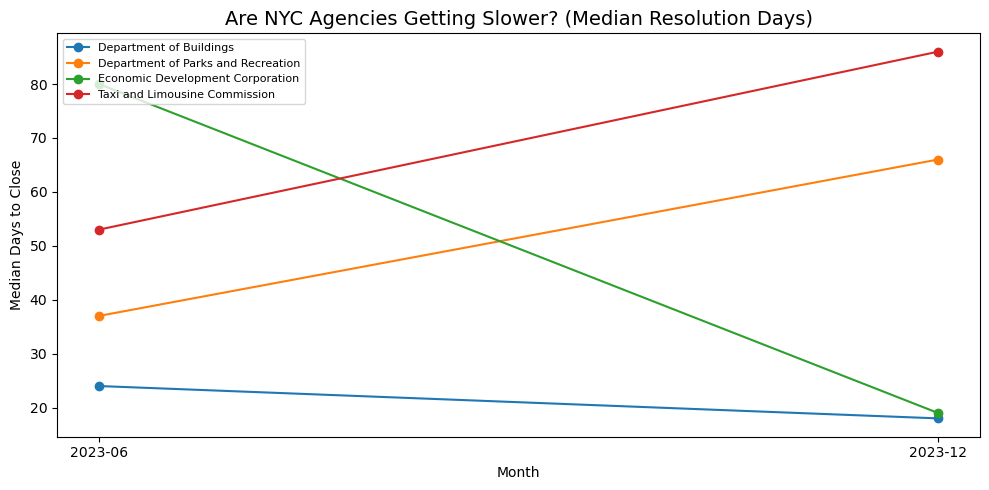

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

for agency in pivot.columns:
    ax.plot(pivot.index, pivot[agency], marker='o', label=agency)

ax.set_title('Are NYC Agencies Getting Slower? (Median Resolution Days)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Median Days to Close')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('agency_trend.png', dpi=150)
plt.show()

In [26]:
summary = closed.groupby('agency_name')['resolution_days'].agg(
    complaints='count',
    median_days='median',
    pct_over_30_days=lambda x: round((x > 30).sum() / len(x) * 100, 1)
).query('complaints >= 50').sort_values('median_days', ascending=False)

print(summary.head(10))

                                                    complaints  median_days  \
agency_name                                                                   
Taxi and Limousine Commission                              214         54.5   
Department of Parks and Recreation                         586         42.0   
Economic Development Corporation                           402         20.0   
Department of Buildings                                    476         19.0   
Department of Housing Preservation and Development        3380          3.0   
Department of Consumer and Worker Protection                68          2.0   
Department of Environmental Protection                     776          2.0   
Department of Health and Mental Hygiene                    487          2.0   
Department of Sanitation                                  1754          2.0   
Department of Transportation                               814          2.0   

                                                   